In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Импортируем необходимые модули из scikit-learn:
# - train_test_split для разбиения данных на обучающую и тестовую выборки
# - learning_curve для построения кривой обучения
# - DecisionTreeClassifier и plot_tree для создания и визуализации дерева решений (алгоритм CART)
# - classification_report, confusion_matrix, accuracy_score, roc_curve, auc, precision_recall_curve для оценки качества модели
# - SimpleImputer для обработки пропущенных значений
# - SelectKBest и f_classif для отбора наиболее значимых признаков с использованием статистического теста ANOVA
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, precision_recall_curve
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif

In [18]:

data = pd.read_csv('../data/gender_submission.csv')

# Для примера создаём ещё два искусственных признака, чтобы иметь возможность выбрать из нескольких признаков.
data['Feature1'] = data['PassengerId'] % 3
data['Feature2'] = (data['PassengerId'] // 10) % 5

X = data[['PassengerId', 'Feature1', 'Feature2']]
y = data['Survived']

# Создаём объект SimpleImputer, который заменяет пропуски средним значением по столбцу.
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 100)

In [19]:

print(data.head())

   PassengerId  Survived  Feature1  Feature2
0          892         0         1         4
1          893         1         2         4
2          894         0         0         4
3          895         0         1         4
4          896         1         2         4


In [20]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
 2   Feature1     418 non-null    int64
 3   Feature2     418 non-null    int64
dtypes: int64(4)
memory usage: 13.2 KB
None


In [21]:
print(data.describe())

       PassengerId    Survived    Feature1    Feature2
count   418.000000  418.000000  418.000000  418.000000
mean   1100.500000    0.363636    1.000000    1.990431
std     120.810458    0.481622    0.816497    1.446041
min     892.000000    0.000000    0.000000    0.000000
25%     996.250000    0.000000    0.000000    1.000000
50%    1100.500000    0.000000    1.000000    2.000000
75%    1204.750000    1.000000    2.000000    3.000000
max    1309.000000    1.000000    2.000000    4.000000


In [22]:

# Выбираем те признаки, которые лучше всего объясняют дисперсию целевой переменной.
selector = SelectKBest(score_func=f_classif, k=2)
X_new = selector.fit_transform(X, y)

# Метод get_support() возвращает булев массив, где True означает, что признак был выбран.
all_features = np.array(['PassengerId', 'Feature1', 'Feature2'])
selected_features = all_features[selector.get_support()]
print("Выбранные признаки:", selected_features)

Выбранные признаки: ['Feature1' 'Feature2']


In [23]:

X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.3, random_state=42)

# Обучение модели CART  с ограниченной глубиной
clf = DecisionTreeClassifier(random_state=42, max_depth=3)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

# precision (Точность)
# recall (Полнота) - Показывает, насколько хорошо модель находит все объекты данного класса.
# f1-score (F1-мера) -Среднее гармоническое между precision и recall
# support -Количество объектов в тестовой выборке для каждого класса.
# accuracy (Точность модели в целом)
# macro avg (Среднее арифметическое для всех классов)
# weighted avg (Средневзвешенное значение по количеству объектов в классах)
print("Отчет по классификации:")
print(classification_report(y_test, y_pred, digits=4))

Отчет по классификации:
              precision    recall  f1-score   support

           0     0.7117    0.9294    0.8061        85
           1     0.6000    0.2195    0.3214        41

    accuracy                         0.6984       126
   macro avg     0.6559    0.5745    0.5638       126
weighted avg     0.6754    0.6984    0.6484       126



In [24]:

# Выводим матрицу ошибок
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))

Матрица ошибок:
[[79  6]
 [32  9]]


In [25]:

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Accuracy: 0.6984


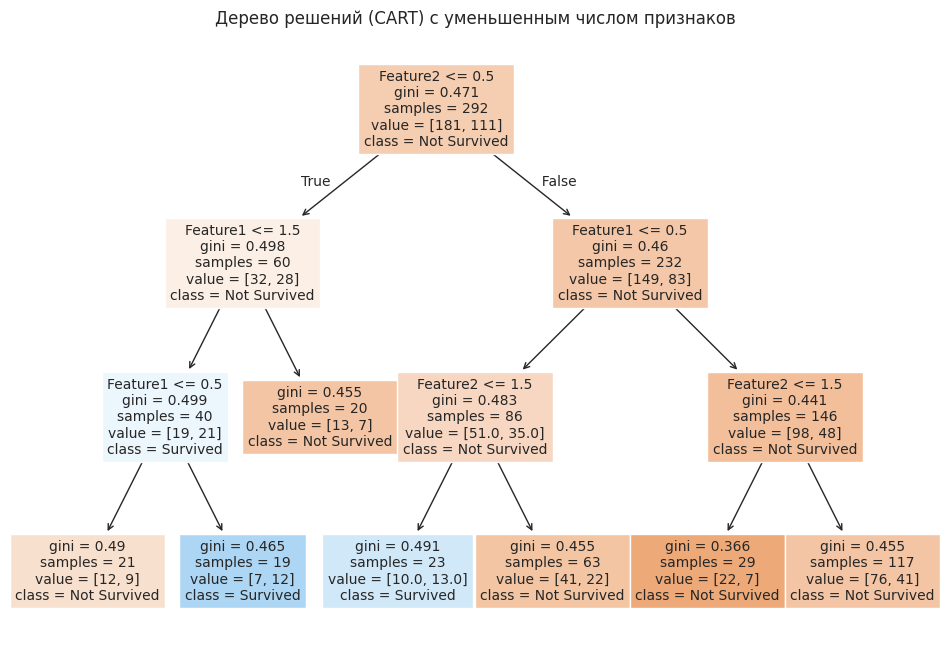

In [26]:

# - filled=True окрашивает узлы в зависимости от класса,
# - feature_names передаёт имена выбранных признаков,
# - class_names задаёт имена классов для удобства интерпретации.
plt.figure(figsize=(12, 8))
plot_tree(clf, filled=True, feature_names=selected_features, class_names=['Not Survived', 'Survived'])
plt.title("Дерево решений (CART) с уменьшенным числом признаков")
plt.show()

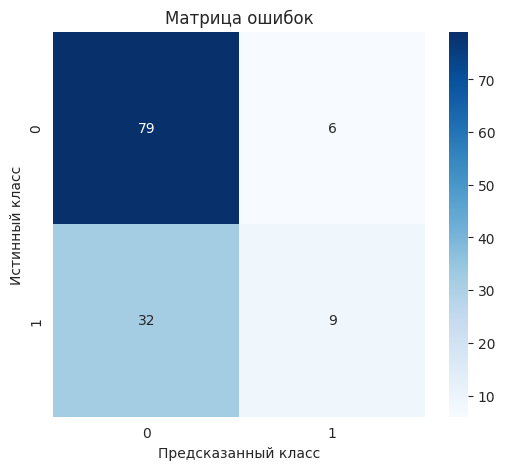

In [27]:

# График 1. Визуализация дерева решений

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Матрица ошибок")
plt.show()

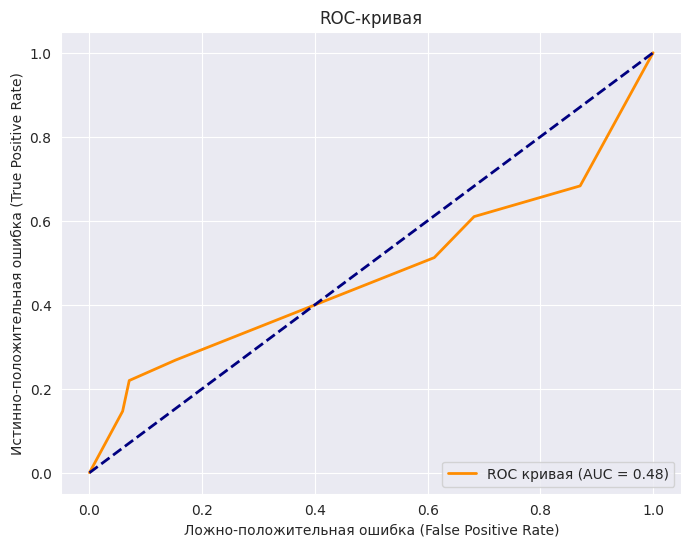

In [28]:

y_proba = clf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)  # Вычисляем площадь под ROC-кривой (AUC)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC кривая (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Ложно-положительная ошибка (False Positive Rate)')
plt.ylabel('Истинно-положительная ошибка (True Positive Rate)')
plt.title('ROC-кривая')
plt.legend(loc="lower right")
plt.show()

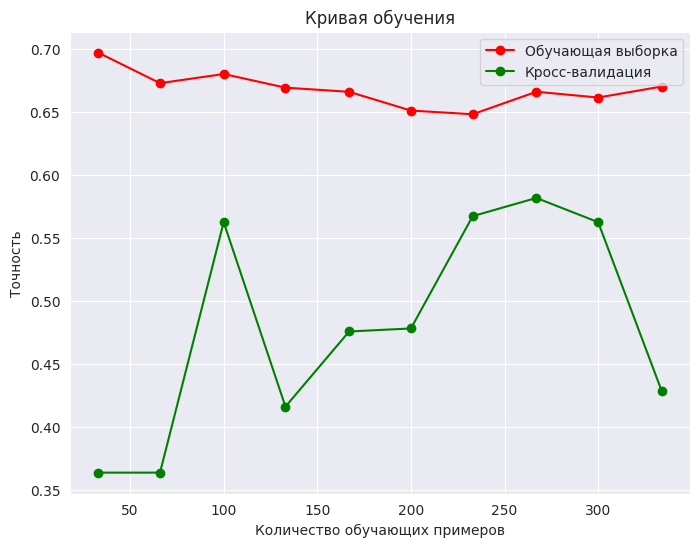

In [30]:

# Кривая обучения
# Кривая обучения показывает, как изменяется точность модели на обучающей выборке и при кросс-валидации в зависимости от размера обучающей выборки.
# Это помогает выявить проблему переобучения или недообучения.
train_sizes, train_scores, test_scores = learning_curve(
    clf, X, y, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Обучающая выборка")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Кросс-валидация")
plt.title("Кривая обучения")
plt.xlabel("Количество обучающих примеров")
plt.ylabel("Точность")
plt.legend(loc="best")
plt.grid(True)
plt.show()

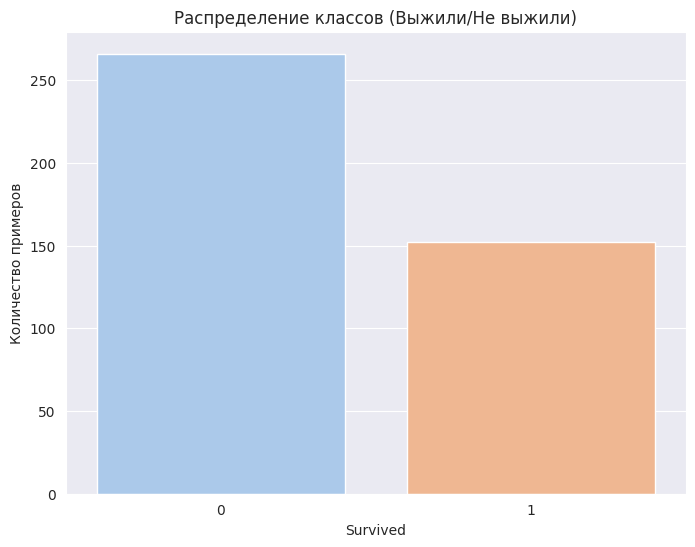

In [31]:

# Распределение классов в полном датасете
# Для оценки дисбаланса классов используем countplot, который показывает количество примеров каждого класса.
plt.figure(figsize=(8, 6))
sns.countplot(x='Survived',hue='Survived', data=data, palette='pastel', legend=False)
plt.title("Распределение классов (Выжили/Не выжили)")
plt.xlabel("Survived")
plt.ylabel("Количество примеров")
plt.show()

In [32]:

# # В процессе работы была проведена предварительная обработка данных, включая заполнение пропусков и отбор наиболее значимых признаков с использованием SelectKBest (статистический тест ANOVA F). Это позволило выбрать два наиболее важных признака для обучения модели. Затем данные были разделены на обучающую и тестовую выборки (70/30), а дерево решений (CART) обучено с ограниченной глубиной (max_depth=3). Такой подход помогает избежать переобучения, но может снизить сложность модели.
# Результаты модели показали общую точность (accuracy) 69.84%, однако детальный анализ метрик выявил дисбаланс в классификации классов. Для класса 0 (не выжил) модель показала высокую полноту (recall = 92.94%), но для класса 1 (выжил) полнота оказалась очень низкой (recall = 21.95%). Это означает, что модель хорошо идентифицирует людей, не выживших, но плохо предсказывает выживших пассажиров. Метрика precision (60.00% для класса 1) также указывает на проблемы с правильной идентификацией этого класса.
# Дополнительные визуализации, такие как ROC-кривая (AUC), Precision-Recall кривая, матрица ошибок и кривая обучения, помогли проанализировать качество модели. ROC-кривая показала ограниченную способность модели различать классы, а Precision-Recall кривая подтвердила низкую предсказательную способность для редкого класса. Матрица ошибок наглядно продемонстрировала, что модель часто ошибается, предсказывая выживших как не выживших. Для улучшения точности модели рекомендуется добавить больше информативных признаков (например, возраст, класс билета, пол), а также использовать методы балансировки классов, такие как увеличение выборки редкого класса (oversampling) или взвешивание классов в модели дерева решений.
# #
